In [3]:
# ── OTT Platform Analysis ──
# Step 1: Imports & Load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ott_platform_data.csv")
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


ModuleNotFoundError: No module named 'numpy'

In [ ]:
# Step 2: Data Cleaning

# seasons & episodes are empty strings for Movies/Stand-Up — convert to NaN then 0
df['seasons']  = pd.to_numeric(df['seasons'],  errors='coerce').fillna(0).astype(int)
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce').fillna(0).astype(int)

# Confirm no remaining nulls
print("Nulls after cleaning:\n", df.isnull().sum())
print("\nShape:", df.shape)

Nulls after cleaning:
 content_id                      0
title                           0
platform                        0
content_type                    0
genre                           0
language                        0
country                         0
age_rating                      0
release_year                    0
release_month                   0
seasons                         0
episodes                        0
runtime_min                     0
imdb_score                      0
rotten_tomatoes_pct             0
audience_score_pct              0
monthly_views_millions          0
avg_watch_time_min              0
completion_rate_pct             0
rewatches                       0
subscribers_gained              0
subscribers_lost                0
revenue_usd_millions            0
production_cost_usd_millions    0
primary_device                  0
subscription_plan               0
resolution                      0
user_reviews                    0
likes                    

In [ ]:
# Step 3: Feature Engineering

# ROI = (revenue - production_cost) / production_cost * 100
df['roi_pct'] = ((df['revenue_usd_millions'] - df['production_cost_usd_millions'])
                 / df['production_cost_usd_millions'] * 100).round(2)

# Watch efficiency = avg_watch_time / runtime
df['watch_efficiency'] = (df['avg_watch_time_min'] / df['runtime_min']).round(3)

# Net subscribers
df['net_subscribers'] = df['subscribers_gained'] - df['subscribers_lost']

# Engagement score (normalised composite)
df['engagement_score'] = (
    df['completion_rate_pct'] * 0.4 +
    df['audience_score_pct']  * 0.3 +
    df['imdb_score'] * 10     * 0.3
).round(2)

print(df[['title','roi_pct','watch_efficiency','net_subscribers','engagement_score']].head())


         title  roi_pct  watch_efficiency  net_subscribers  engagement_score
0   Backlash 4   -81.80             0.874            56696             55.38
1     Deadlock   -71.22             0.735           367380             49.04
2     Overload   -50.01             0.862           426654             66.10
3        Nexus   -90.41             0.250           -17126             62.54
4  Crossfire 2   -99.45             0.934           105909             80.74


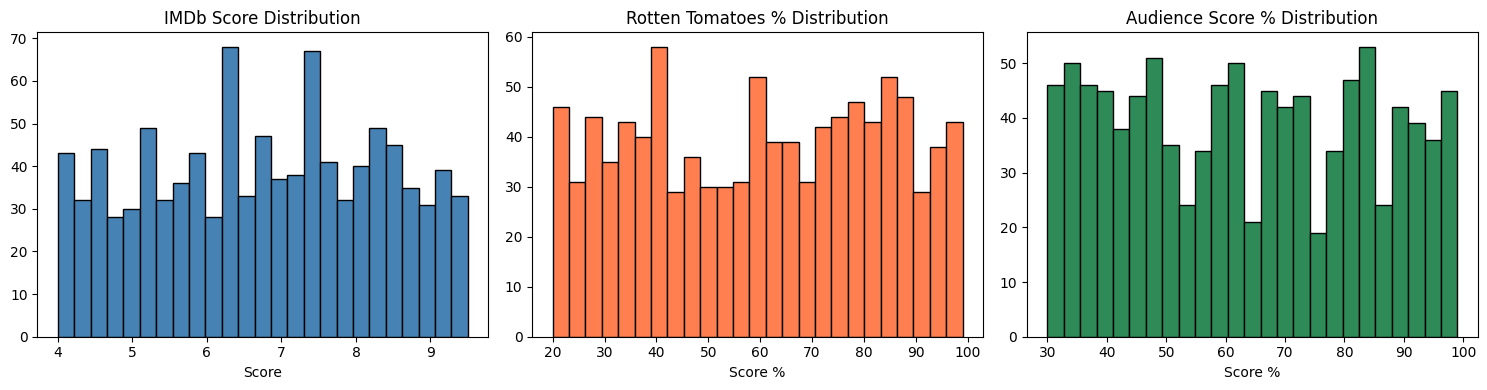

In [ ]:
# Step 4: EDA — Score Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['imdb_score'], bins=25, color='steelblue', edgecolor='black')
axes[0].set_title('IMDb Score Distribution')
axes[0].set_xlabel('Score')

axes[1].hist(df['rotten_tomatoes_pct'], bins=25, color='coral', edgecolor='black')
axes[1].set_title('Rotten Tomatoes % Distribution')
axes[1].set_xlabel('Score %')

axes[2].hist(df['audience_score_pct'], bins=25, color='seagreen', edgecolor='black')
axes[2].set_title('Audience Score % Distribution')
axes[2].set_xlabel('Score %')

plt.tight_layout()
plt.show()


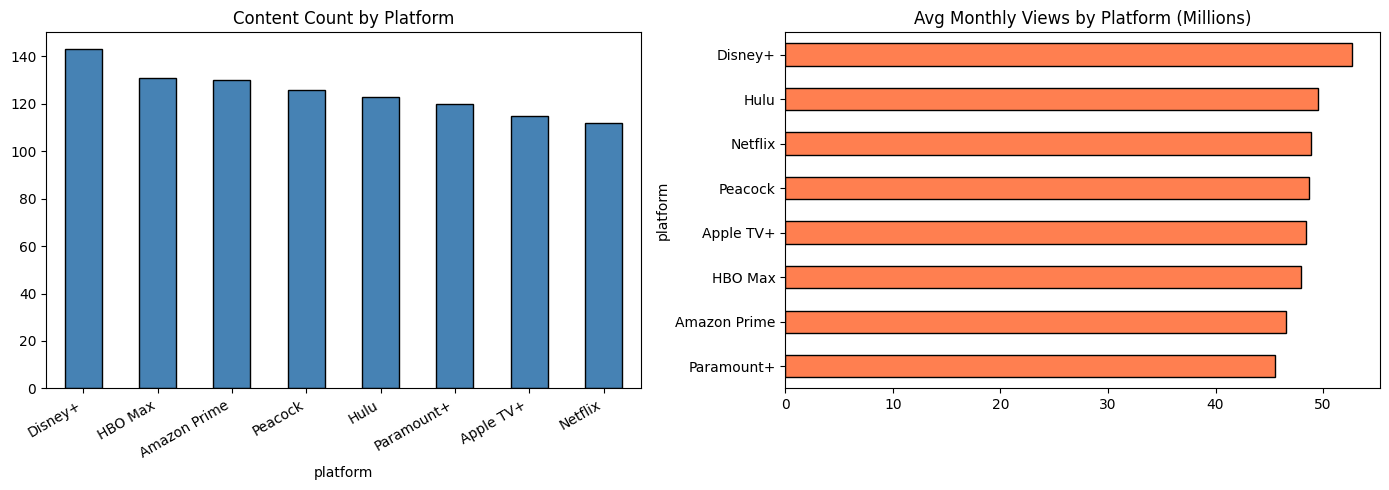

In [ ]:
# Step 5: EDA — Content by Platform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['platform'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Content Count by Platform')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

df.groupby('platform')['monthly_views_millions'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Avg Monthly Views by Platform (Millions)')

plt.tight_layout()
plt.show()


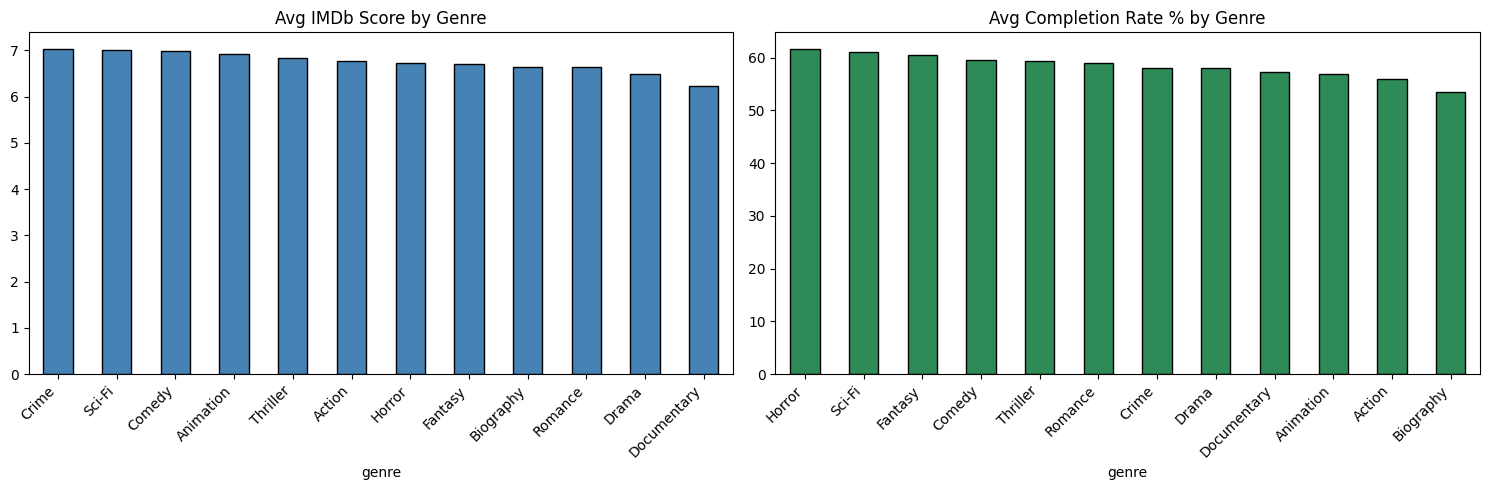

In [ ]:
# Step 6: EDA — Genre Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df.groupby('genre')['imdb_score'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Avg IMDb Score by Genre')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

df.groupby('genre')['completion_rate_pct'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Avg Completion Rate % by Genre')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


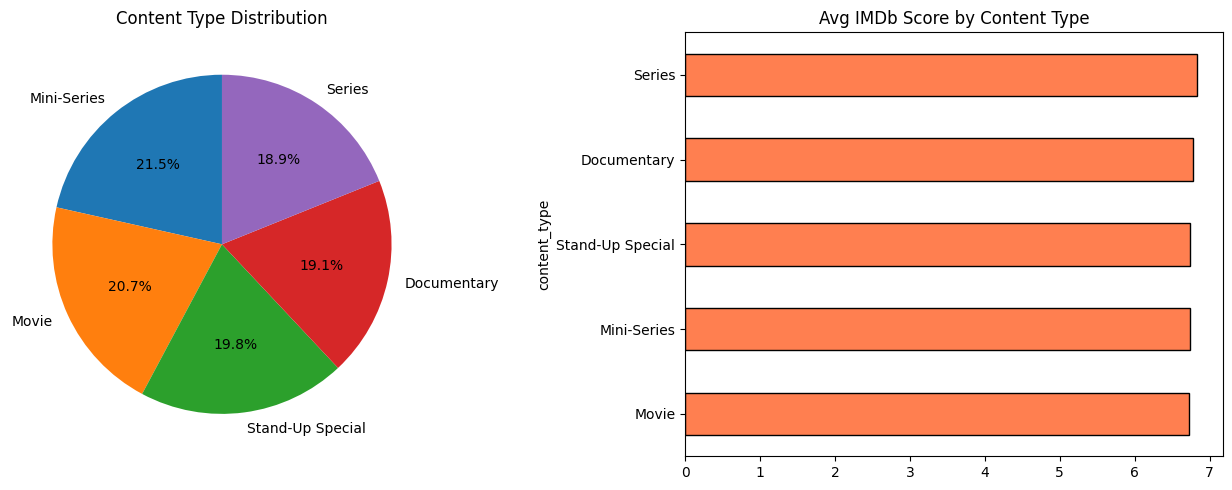

In [ ]:
# Step 7: EDA — Content Type Breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df['content_type'].value_counts().plot(
    kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Content Type Distribution')
axes[0].set_ylabel('')

df.groupby('content_type')['imdb_score'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Avg IMDb Score by Content Type')

plt.tight_layout()
plt.show()


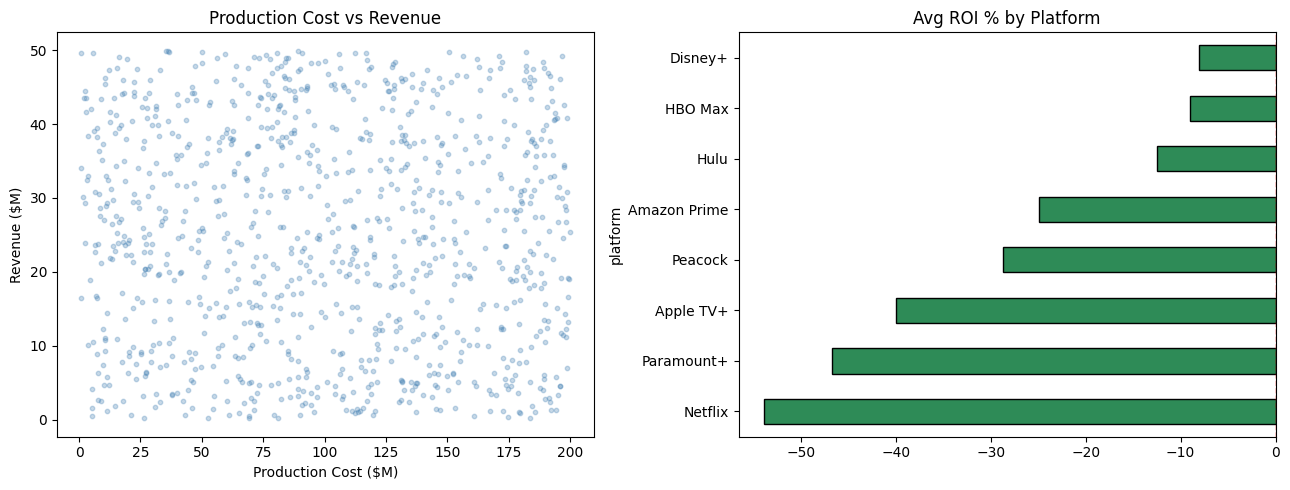

In [ ]:
# Step 8: EDA — Financial Analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['production_cost_usd_millions'], df['revenue_usd_millions'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Production Cost ($M)')
axes[0].set_ylabel('Revenue ($M)')
axes[0].set_title('Production Cost vs Revenue')

df.groupby('platform')['roi_pct'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Avg ROI % by Platform')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()


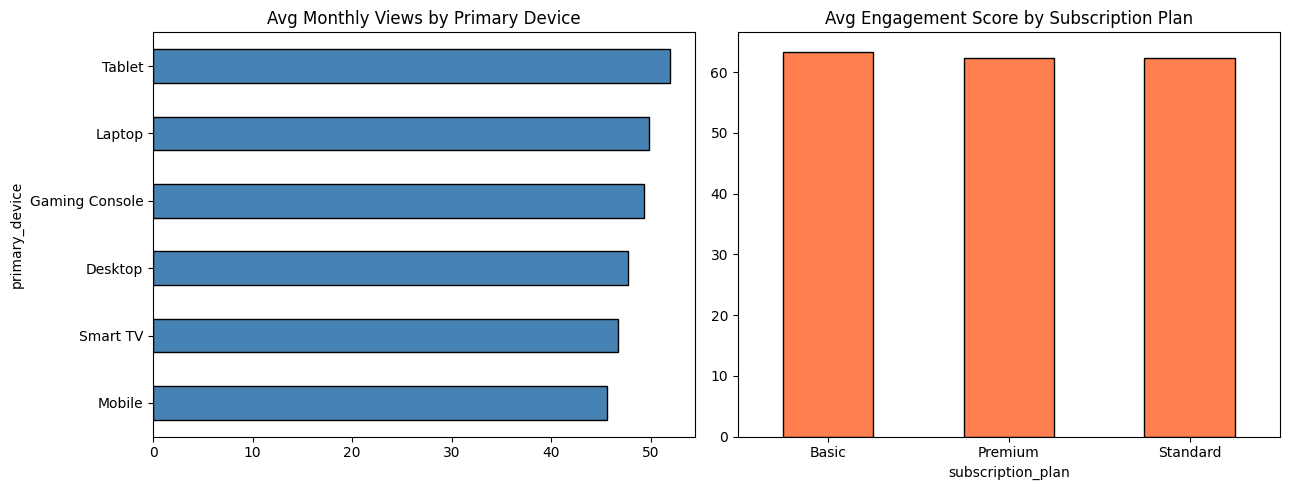

In [ ]:
# Step 9: EDA — Engagement & Viewing Behaviour
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.groupby('primary_device')['monthly_views_millions'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Avg Monthly Views by Primary Device')

df.groupby('subscription_plan')['engagement_score'].mean().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Avg Engagement Score by Subscription Plan')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


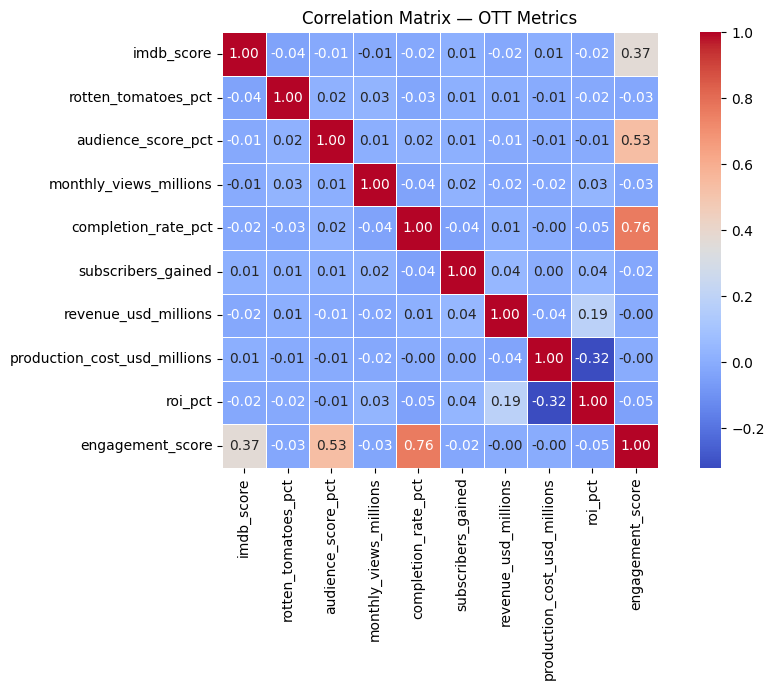

In [ ]:
# Step 10: EDA — Correlation Heatmap
numeric_cols = ['imdb_score', 'rotten_tomatoes_pct', 'audience_score_pct',
                'monthly_views_millions', 'completion_rate_pct',
                'subscribers_gained', 'revenue_usd_millions',
                'production_cost_usd_millions', 'roi_pct', 'engagement_score']

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix — OTT Metrics')
plt.tight_layout()
plt.show()


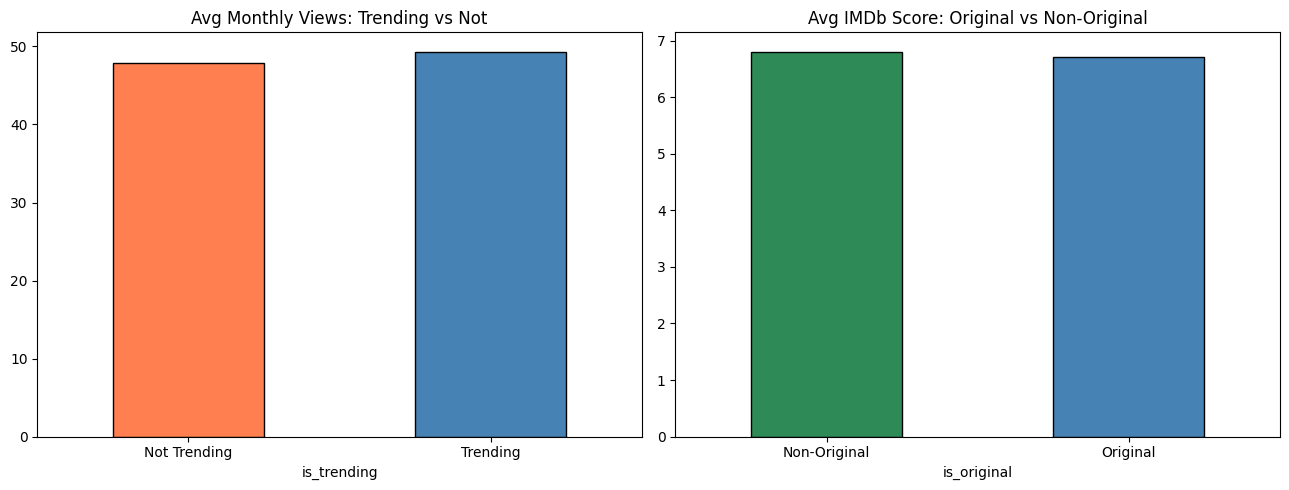

In [ ]:
# Step 11: EDA — Trending vs Non-Trending
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.groupby('is_trending')['monthly_views_millions'].mean().plot(
    kind='bar', ax=axes[0], color=['coral', 'steelblue'], edgecolor='black')
axes[0].set_title('Avg Monthly Views: Trending vs Not')
axes[0].set_xticklabels(['Not Trending', 'Trending'], rotation=0)

df.groupby('is_original')['imdb_score'].mean().plot(
    kind='bar', ax=axes[1], color=['seagreen', 'steelblue'], edgecolor='black')
axes[1].set_title('Avg IMDb Score: Original vs Non-Original')
axes[1].set_xticklabels(['Non-Original', 'Original'], rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# ── Step 1: Setup ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline

# Load & clean (same as EDA notebook)
df = pd.read_csv("ott_platform_data.csv")
df['seasons']  = pd.to_numeric(df['seasons'],  errors='coerce').fillna(0).astype(int)
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce').fillna(0).astype(int)
df['roi_pct']          = ((df['revenue_usd_millions'] - df['production_cost_usd_millions'])
                           / df['production_cost_usd_millions'] * 100).round(2)
df['watch_efficiency'] = (df['avg_watch_time_min'] / df['runtime_min']).round(3)
df['net_subscribers']  = df['subscribers_gained'] - df['subscribers_lost']
df['engagement_score'] = (df['completion_rate_pct']*0.4 +
                           df['audience_score_pct']*0.3 +
                           df['imdb_score']*10*0.3).round(2)
print("Data ready:", df.shape)


Data ready: (1000, 40)


In [ ]:
# ── Step 2: Target & Features ──
# TASK: Predict whether content is TRENDING (binary classification)
# Target: is_trending → 1 = Yes, 0 = No

df['target'] = (df['is_trending'] == 'Yes').astype(int)
print("Class balance:\n", df['target'].value_counts())

# Encode categoricals
le = LabelEncoder()
cat_cols = ['platform', 'content_type', 'genre', 'language', 'country',
            'age_rating', 'primary_device', 'subscription_plan',
            'resolution', 'is_original', 'is_award_winning']
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

features = ['platform', 'content_type', 'genre', 'language', 'country',
            'age_rating', 'release_year', 'release_month',
            'seasons', 'episodes', 'runtime_min',
            'imdb_score', 'rotten_tomatoes_pct', 'audience_score_pct',
            'monthly_views_millions', 'avg_watch_time_min',
            'completion_rate_pct', 'rewatches',
            'subscribers_gained', 'subscribers_lost',
            'revenue_usd_millions', 'production_cost_usd_millions',
            'primary_device', 'subscription_plan', 'resolution',
            'user_reviews', 'likes', 'shares',
            'available_in_countries', 'subtitles_available', 'dubbed_languages',
            'is_original', 'is_award_winning',
            'roi_pct', 'watch_efficiency', 'net_subscribers', 'engagement_score']

X = df_enc[features].dropna()
y = df_enc.loc[X.index, 'target']
print(f"\nFeature matrix: {X.shape} | Target: {y.shape}")


Class balance:
 target
0    511
1    489
Name: count, dtype: int64

Feature matrix: (1000, 37) | Target: (1000,)


In [ ]:
# ── Step 3: Train / Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train positive rate: {y_train.mean():.2%}")
print(f"Test  positive rate: {y_test.mean():.2%}")


Train: 800 | Test: 200
Train positive rate: 48.88%
Test  positive rate: 49.00%


In [ ]:
# ── Step 4: Train Models ──
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, preds)
    auc  = roc_auc_score(y_test, proba)
    cv   = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()

    results[name] = {'Accuracy': acc, 'ROC-AUC': auc,
                     'CV ROC-AUC (5-fold)': cv,
                     'preds': preds, 'proba': proba}
    print(f"{name:25s} | Acc={acc:.4f} | AUC={auc:.4f} | CV-AUC={cv:.4f}")


Logistic Regression       | Acc=0.4350 | AUC=0.4261 | CV-AUC=0.5049
Random Forest             | Acc=0.4700 | AUC=0.4439 | CV-AUC=0.5292
Gradient Boosting         | Acc=0.4750 | AUC=0.4758 | CV-AUC=0.4773


C:\Users\anant\AppData\Local\Temp\ipykernel_7640\98920557.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(names, rotation=15, ha='right')
C:\Users\anant\AppData\Local\Temp\ipykernel_7640\98920557.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(names, rotation=15, ha='right')
C:\Users\anant\AppData\Local\Temp\ipykernel_7640\98920557.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(names, rotation=15, ha='right')


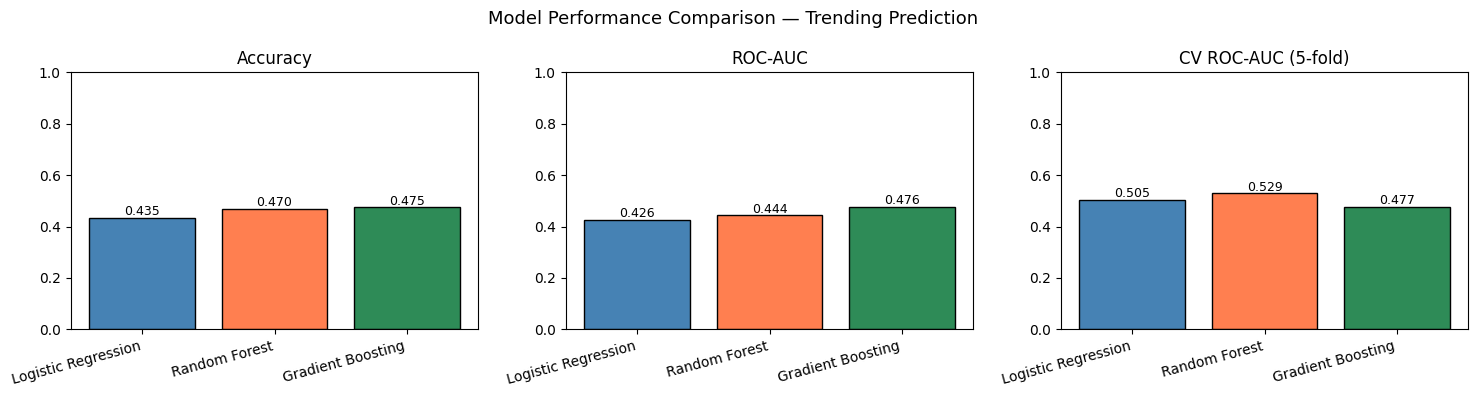

In [ ]:
# ── Step 5: Performance Comparison Bar Chart ──
metrics = ['Accuracy', 'ROC-AUC', 'CV ROC-AUC (5-fold)']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, metric in enumerate(metrics):
    vals  = [results[m][metric] for m in results]
    names = list(results.keys())
    bars  = axes[i].bar(names, vals,
                        color=['steelblue', 'coral', 'seagreen'],
                        edgecolor='black')
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(names, rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle("Model Performance Comparison — Trending Prediction", fontsize=13)
plt.tight_layout()
plt.show()


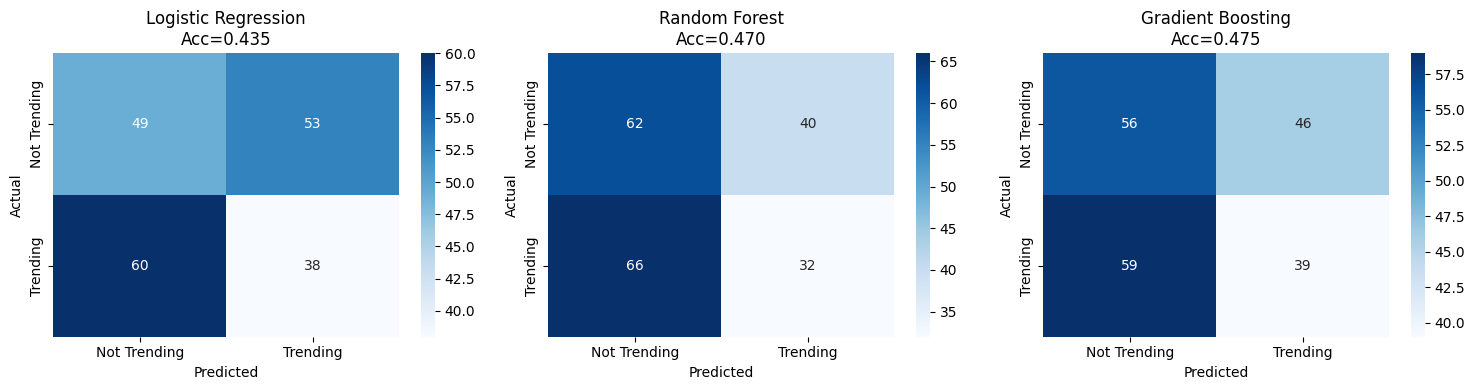

In [ ]:
# ── Step 6: Confusion Matrices ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Trending', 'Trending'],
                yticklabels=['Not Trending', 'Trending'])
    ax.set_title(f'{name}\nAcc={res["Accuracy"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


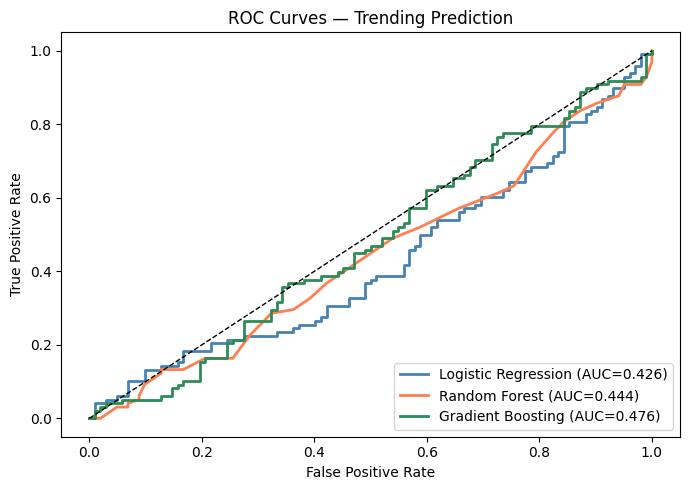

In [ ]:
# ── Step 7: ROC Curves ──
plt.figure(figsize=(7, 5))
colors = ['steelblue', 'coral', 'seagreen']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC={res['ROC-AUC']:.3f})")

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Trending Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
# ── Step 8: Classification Report (Best Model) ──
best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
best_preds = results[best_name]['preds']

print(f"Best Model: {best_name}\n")
print(classification_report(y_test, best_preds,
                             target_names=['Not Trending', 'Trending']))


Best Model: Gradient Boosting

              precision    recall  f1-score   support

Not Trending       0.49      0.55      0.52       102
    Trending       0.46      0.40      0.43        98

    accuracy                           0.47       200
   macro avg       0.47      0.47      0.47       200
weighted avg       0.47      0.47      0.47       200



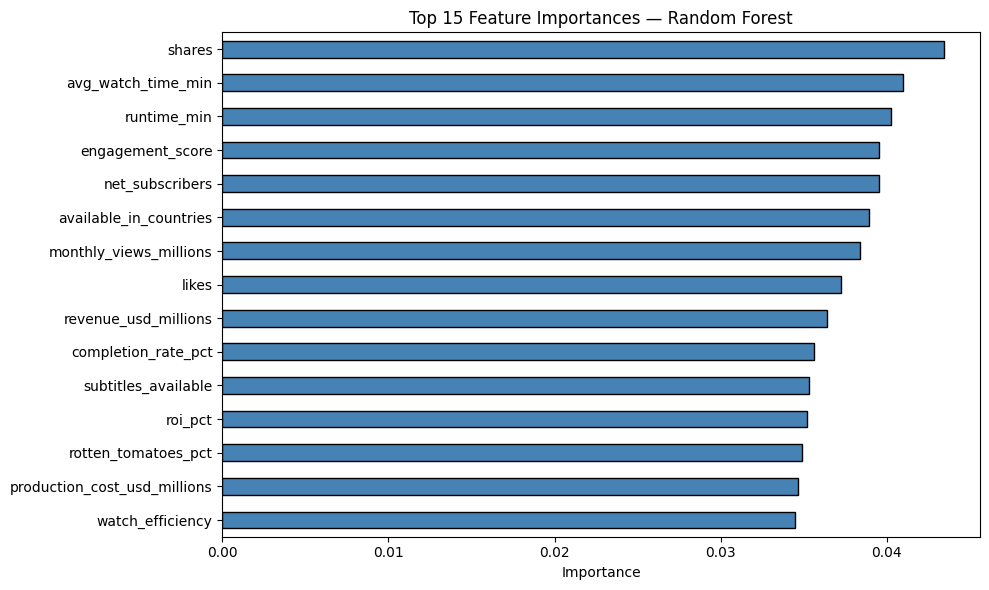

In [ ]:
# ── Step 9: Feature Importance (Random Forest) ──
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()


In [ ]:
summary = pd.DataFrame({
    name: {
        'Accuracy':           f"{res['Accuracy'] * 100:.2f}%",
        'ROC-AUC':            f"{res['ROC-AUC'] * 100:.2f}%",
        'CV ROC-AUC (5-fold)':f"{res['CV ROC-AUC (5-fold)'] * 100:.2f}%"
    }
    for name, res in results.items()
}).T

print("\n── Model Performance Summary ──")
print(summary.to_string())


── Model Performance Summary ──
                    Accuracy ROC-AUC CV ROC-AUC (5-fold)
Logistic Regression   43.50%  42.61%              50.49%
Random Forest         47.00%  44.39%              52.92%
Gradient Boosting     47.50%  47.58%              47.73%
